In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from astropy.time import Time
import matplotlib as mpl
import seaborn as sns
from cycler import cycler
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from glob import glob
from astropy.table import Table
from astropy.visualization import quantity_support

In [51]:
quantity_support()
clrs = sns.color_palette('Set1')
clrs[5] = (255/255, 200/255, 80/255)
color_cycle = cycler('color', list(clrs.as_hex()))
mpl.rc('font', family='serif')
mpl.rc('text', usetex=True)

plt.rc('axes', axisbelow=True, 
       grid=False, prop_cycle=color_cycle)
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')
plt.rcParams['figure.dpi'] = 150

In [3]:
aavso_path = os.path.join('data', 'observations_20260401_RU_Lup','RULupi_AAVSOobservations_20260401_153150.csv')
aavso_points = pd.read_csv(aavso_path)
aavso_points.keys()

Index(['#', 'target', 'auid', 'jd', 'mag', 'uncertainty', 'fainterthan',
       'band', 'type', 'observer', 'airmass', 'transformed'],
      dtype='object')

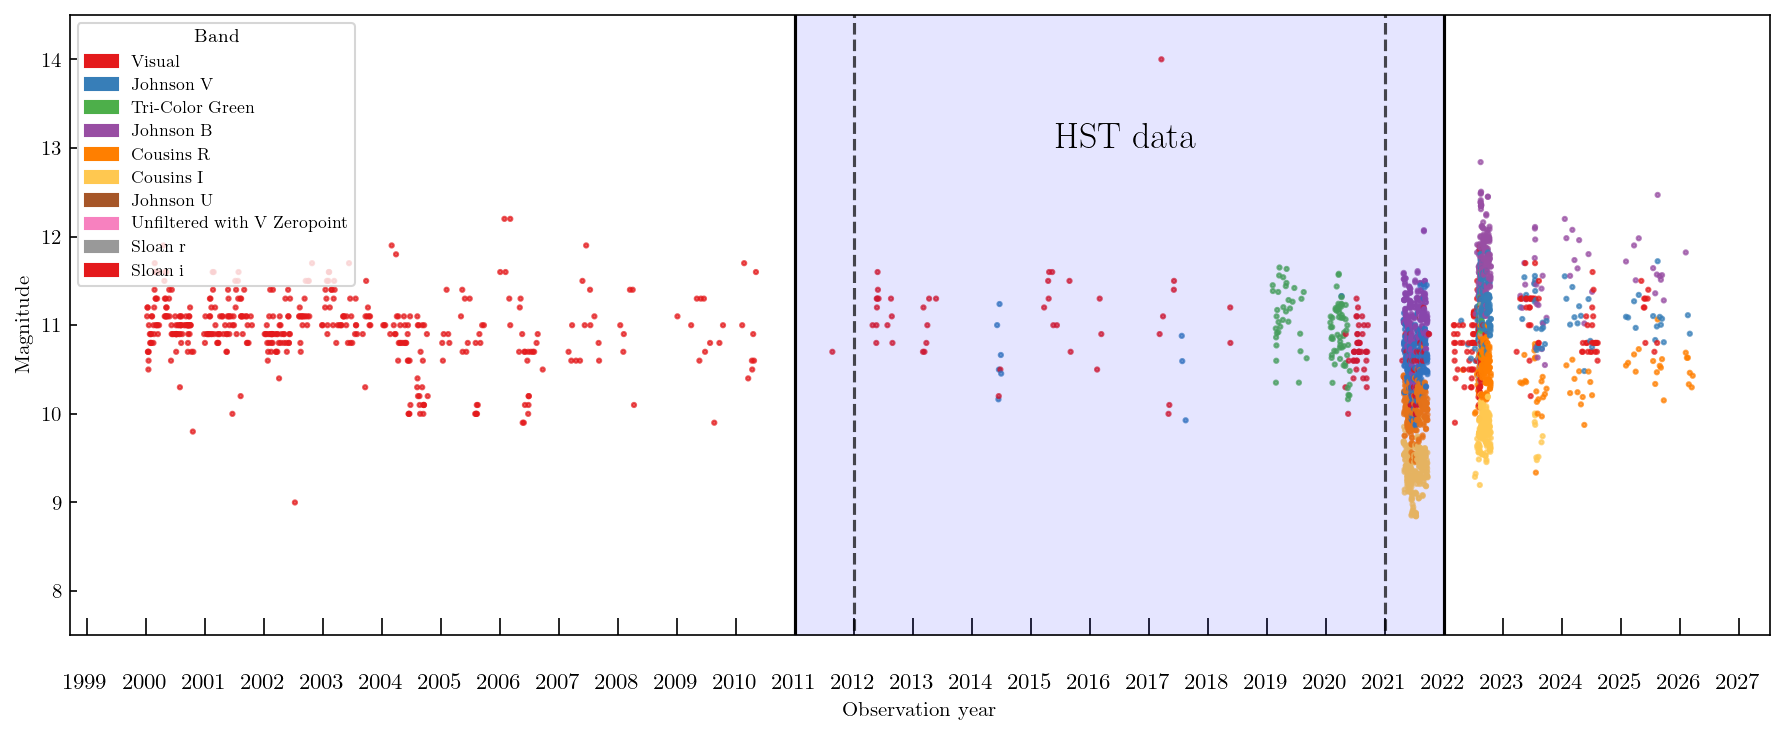

In [193]:
aavso_jd = Time(aavso_points['jd'], format='jd')
x = np.array(aavso_jd.to_value('iso'), dtype='datetime64[D]')

# Map each band to a color
unique_bands = aavso_points['band'].unique()
hex_colors = list(clrs.as_hex())
band_color_map = {band: hex_colors[i % len(hex_colors)] for i, band in enumerate(unique_bands)}
colors = [band_color_map[b] for b in aavso_points['band']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(x, aavso_points['mag'], s=4, c=colors, alpha=0.7)

ax.set_ylim(7.5, 14.5)
ax.set_ylabel('Magnitude')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.tick_params(axis='x', which='major', labelsize=11, pad=18, length=8)
ax.set_xlabel('Observation year')

ax.vlines(np.array(['2011', '2022'], dtype='datetime64[D]'), 7,15, 'black')
ax.vlines(np.array(['2012', '2021'], dtype='datetime64[D]'), 7,15, 'black', '--', alpha=0.7)
ax.fill_between(np.array(['2011', '2022'], dtype='datetime64[D]'), 7,15, alpha=0.1, color='blue')
ax.text(np.array(['2015-06-01'], dtype='datetime64[D]'), 13, 'HST data', size='xx-large')

legend_handles = [mpatches.Patch(color=band_color_map[band], label=band) for band in unique_bands]

ax.legend(handles=legend_handles, title='Band', loc='upper left',
          fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
#get the lines from me:
line_df = pd.read_pickle(os.path.join('data', 'line_df_coadded_bootstrapped_run2.pkl'))
blue_df = pd.read_pickle(os.path.join('data', 'blue_df_coadded_bootstrapped_run2.pkl'))
red_df = pd.read_pickle(os.path.join('data', 'red_df_coadded_bootstrapped_run2.pkl'))

all_df = pd.concat([blue_df, line_df, red_df])

def SNR(signal, noise):
    return np.mean(signal/noise)

def snr_mask(df, low, high):
    ratio = df.apply(lambda r: SNR(r['gauss_flux'], r['gauss_fluxerr']) /
                               SNR(r['flux'], r['fluxerr']), axis=1)
    return df[ratio.between(low, high)]

def peak_mask(df, thresh):
    ratio = df.apply(lambda r: max(r['gauss_flux'].value)/r['params1']['bgl'][0], axis=1)
    mask = np.array(ratio) > thresh
    return ratio, df[mask].copy()

#Drop lines with low peak-significance
_, red_df_peak  = peak_mask(snr_mask(red_df,  1.5, 13),  1.5)
_, blue_df_peak = peak_mask(snr_mask(blue_df, 1.5, 16), 1.5)
_, line_df_peak = peak_mask(snr_mask(line_df, 0.8, 100), 1.5)

all_df_pruned = pd.concat([blue_df_peak, line_df_peak, red_df_peak])

del line_df, blue_df, red_df, red_df_peak, blue_df_peak, line_df_peak

my_lablines = all_df_pruned['labline'].unique()

In [197]:
linelist_file = os.path.join('HST','emission_lines.csv')
linelist = pd.read_csv(linelist_file, skiprows=2)
transitions = []
rows = []
for l in my_lablines:
    transitions.append(linelist["[nu', J']"][linelist['lab_lambda']==l].values[0])
    rows.append(linelist[linelist['lab_lambda']==l].values[0])

print(linelist.keys())
print(rows)

Index(['Line ID', '[nu', J']', 'lab_lambda', 'transition_prob', 'pump_lambda'], dtype='object')
[array(['(4–11)P(5)', '[4,4]', 1613.72, 0.15, 1214.78], dtype=object), array(['(4–6)R(12)', '[4,13]', 1415.33, 0.037, 1213.68], dtype=object), array(['(0–6)P(3)', '[0,2]', 1463.83, 0.074, 1217.64], dtype=object), array(['(0–6)P(2)', '[0,1]', 1460.17, 0.083, 1217.21], dtype=object), array(['(0–5)P(2)', '[0,1]', 1398.95, 0.141, 1217.21], dtype=object), array(['(0–2)P(2)', '[0,1]', 1521.59, 0.032, 1217.21], dtype=object), array(['(1–6)R(3)', '[1,4]', 1431.01, 0.058, 1216.07], dtype=object), array(['(1–6)P(5)', '[1,4]', 1446.12, 0.083, 1216.07], dtype=object), array(['(1–7)R(3)', '[1,4]', 1489.57, 0.094, 1216.07], dtype=object), array(['(1–7)P(5)', '[1,4]', 1504.76, 0.115, 1216.07], dtype=object), array(['(1–6)P(8)', '[1,7]', 1467.08, 0.08, 1215.73], dtype=object), array(['(1–7)R(6)', '[1,7]', 1500.45, 0.101, 1215.73], dtype=object), array(['(3–11)P(1)', '[3,0]', 1636.34, 0.099, 1217.04], dtype=

In [162]:
pk_lines = [(trans, lines) for trans, lines in zip(transitions, my_lablines)]

In [190]:
#calvet lines:
calvet_lines = {'Si IV': 1394,
                'Si IV (2)': 1403,
                'C I': 1463,
                'Mg II': 1466.55,
                'C IV': 1548,
                'Fe II': 1602}

In [118]:
spectrum_files = glob(os.path.join('HST','anonymous37222', '*x1dsum.fits'))
spec = Table.read(spectrum_files[4])
wave = np.concatenate(spec['WAVELENGTH'].value)
flux = np.concatenate(spec['FLUX'].value)

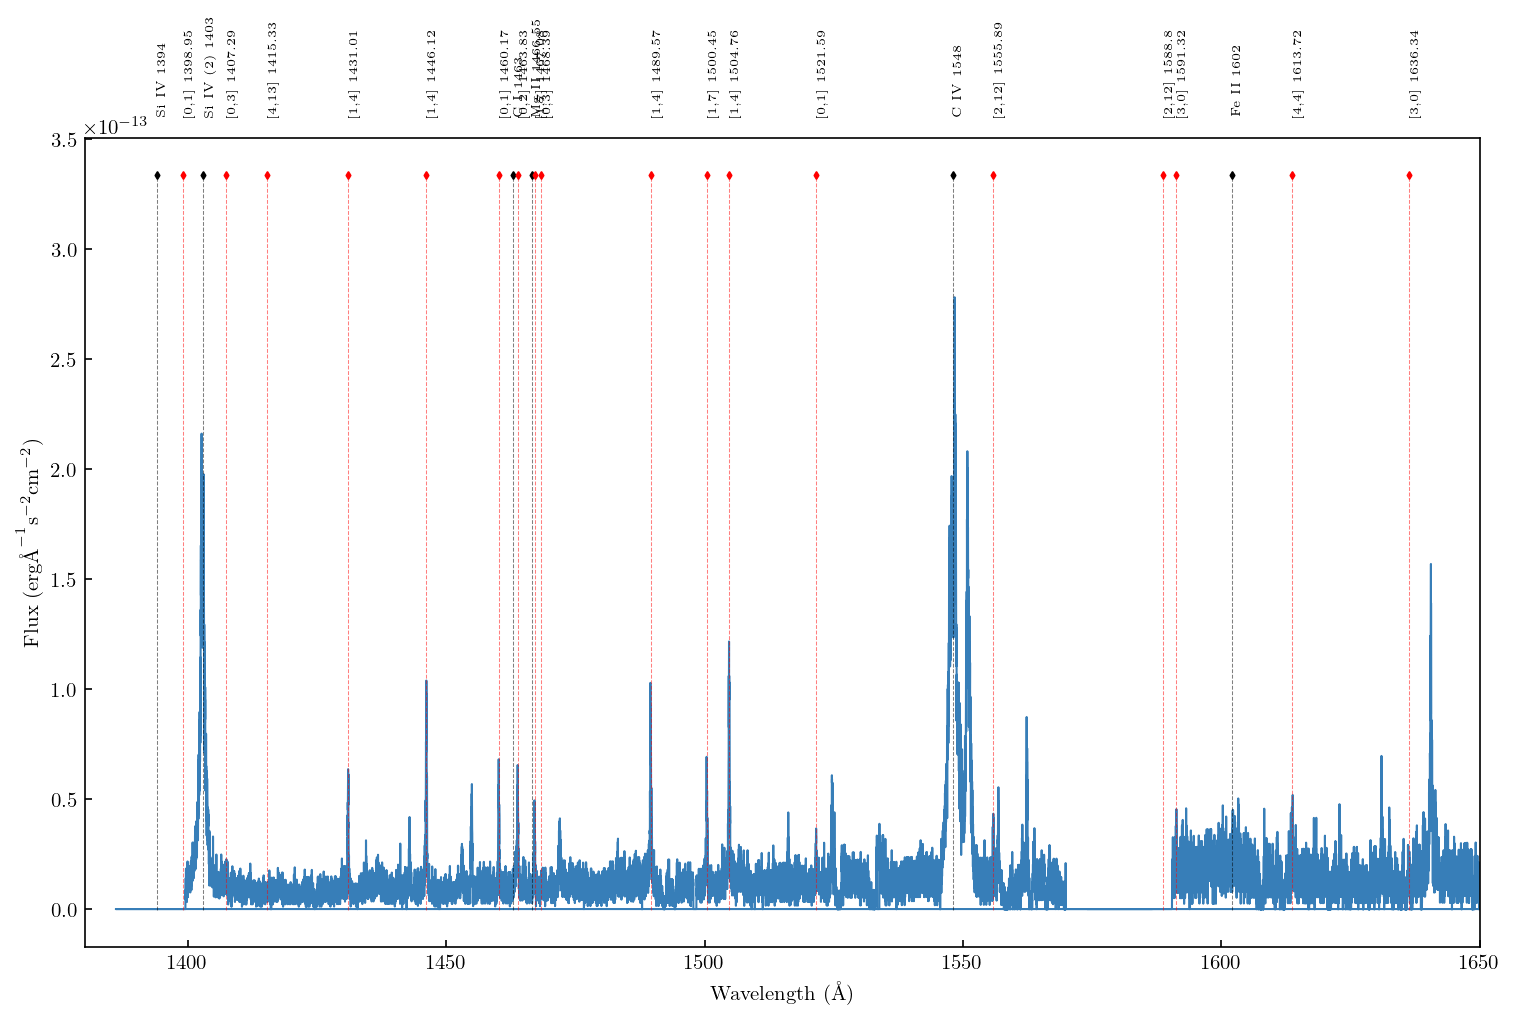

In [191]:
#full spectrum + contaminants
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(wave, flux, c=clrs[1], lw=1)
for key, value in calvet_lines.items():
    ax.vlines(value, min(flux), max(flux)*1.2, 'black', '--', alpha=0.5, lw=0.5)
    ax.scatter(value, [max(flux)*1.2], marker='d', c='black', s=5)
    ax.text(value, (max(flux)*1.3), key+' '+str(value), size='xx-small', rotation='vertical')

for key, value in pk_lines:
    ax.vlines(value, min(flux), max(flux)*1.2, 'red', '--', alpha=0.5, lw=0.5)
    ax.scatter(value, max(flux)*1.2, marker='d', c='red', s=5)
    ax.text(value, (max(flux)*1.3), key+' '+str(value), size='xx-small', rotation='vertical')

ax.set_ylabel(r'Flux (erg$ \mathrm{\AA}^{-1} \textrm{s}^{-2} \textrm{cm}^{-2}$)')
ax.set_xlabel(r'Wavelength ($\mathrm{\AA}$)')
ax.set_xlim(1380, 1650)
plt.show()